In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from numpy.polynomial.legendre import legroots

## Zadanie 1 – Średnia geometryczna odległości węzłów

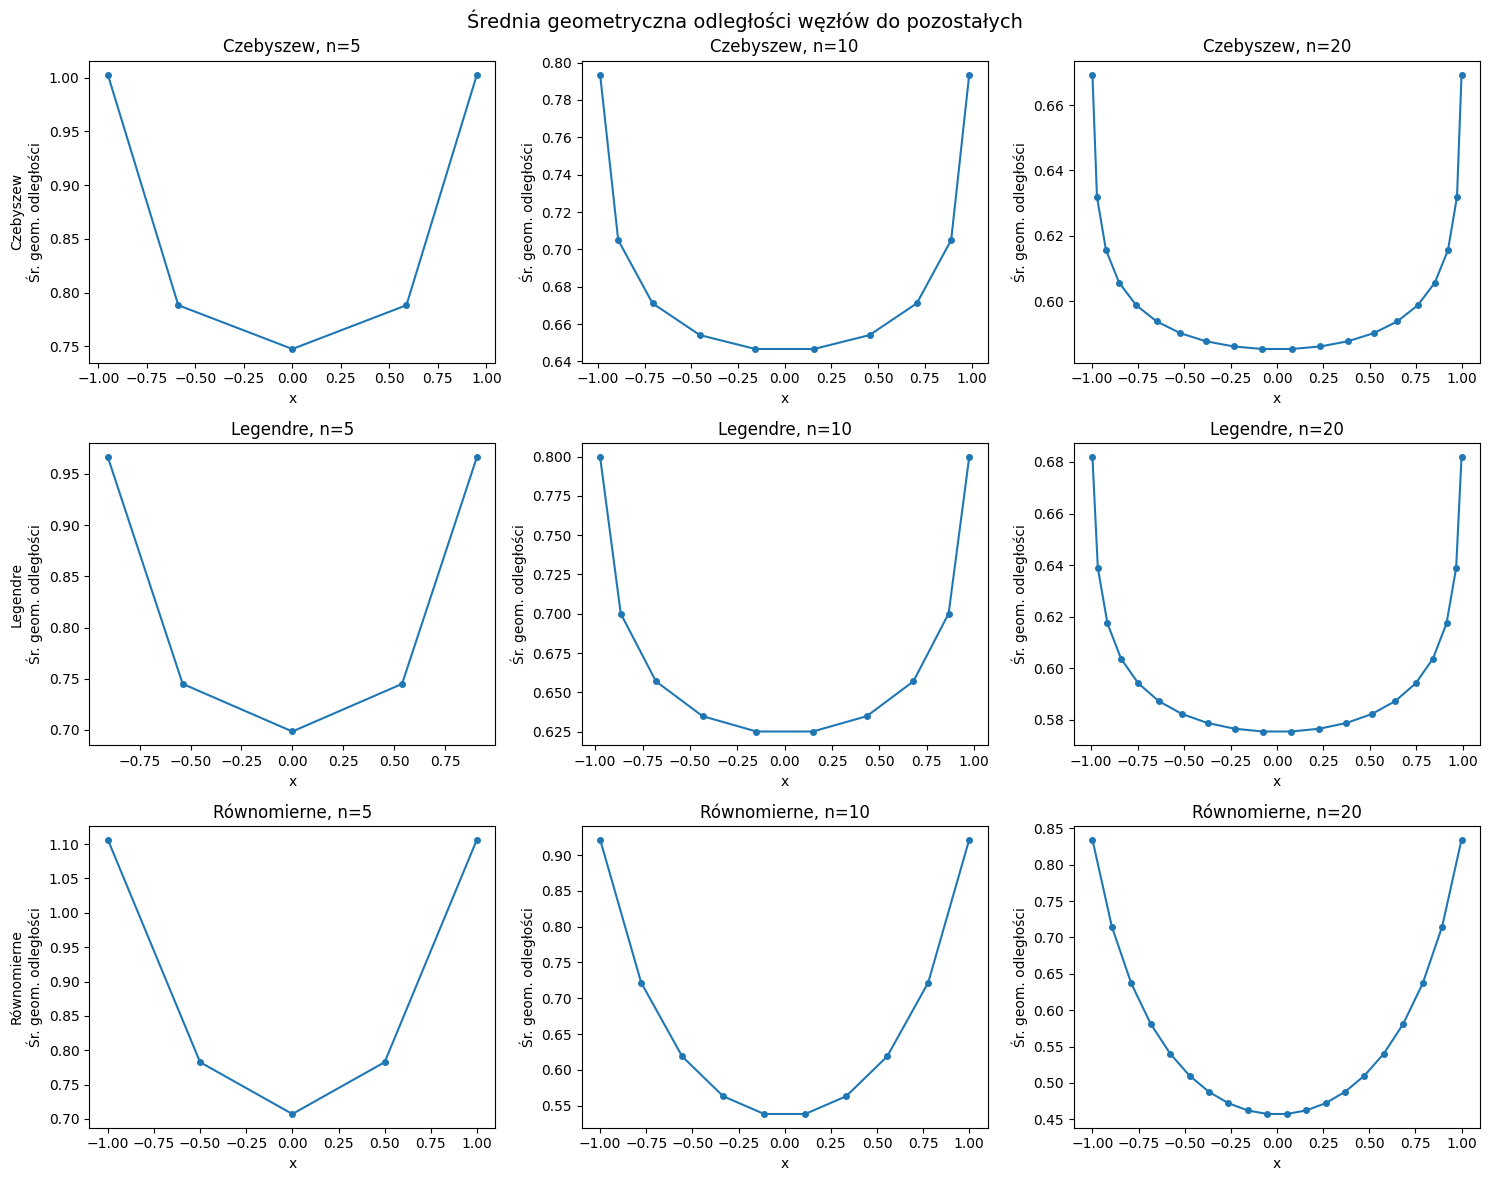

In [ ]:
def plot_geometric_mean_distances(x_nodes, title_suffix='', ax=None):
    n = len(x_nodes)
    geo_means = np.zeros(n)
    for i in range(n):
        dists = np.abs(x_nodes[i] - np.delete(x_nodes, i))
        geo_means[i] = np.prod(dists) ** (1.0 / (n - 1))
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(x_nodes, geo_means, 'o-', markersize=4)
    ax.set_xlabel('x')
    ax.set_ylabel('Śr. geom. odległości')
    ax.set_title(title_suffix)
    return geo_means


def chebyshev_nodes(n, a=-1, b=1):
    j = np.arange(1, n + 1)
    return 0.5 * (a + b) + 0.5 * (b - a) * np.cos((2 * j - 1) / (2 * n) * np.pi)


def legendre_nodes(n):
    coeffs = np.zeros(n + 1)
    coeffs[n] = 1.0
    return legroots(coeffs)


ns = [5, 10, 20]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for col, n in enumerate(ns):
    x_unif = np.linspace(-1, 1, n)
    x_cheb = np.sort(chebyshev_nodes(n))
    x_leg = np.sort(legendre_nodes(n))

    plot_geometric_mean_distances(x_cheb,  f'Czebyszew, n={n}',    axes[0, col])
    plot_geometric_mean_distances(x_leg,   f"Legendre, n={n}",     axes[1, col])
    plot_geometric_mean_distances(x_unif,  f'Równomierne, n={n}',  axes[2, col])

axes[0, 0].set_ylabel('Czebyszew\nŚr. geom. odległości')
axes[1, 0].set_ylabel("Legendre\nŚr. geom. odległości")
axes[2, 0].set_ylabel('Równomierne\nŚr. geom. odległości')

plt.suptitle('Średnia geometryczna odległości węzłów do pozostałych', fontsize=14)
plt.tight_layout()
plt.show()

## Zadanie 2 – Interpolacja funkcji Rungego i exp(cos(x))

### Funkcje pomocnicze

In [3]:
def f1(x):
    return 1.0 / (1.0 + 25.0 * x**2)


def f2(x):
    return np.exp(np.cos(x))


def lagrange_barycentric(x_nodes, y_nodes, x_eval):
    n = len(x_nodes)

    w = np.ones(n)
    for j in range(n):
        for k in range(n):
            if k != j:
                w[j] /= (x_nodes[j] - x_nodes[k])

    x_eval = np.asarray(x_eval, dtype=float)
    result = np.zeros_like(x_eval)
    for i, xi in enumerate(x_eval):
        diffs = xi - x_nodes

        zero_idx = np.where(diffs == 0)[0]
        if len(zero_idx) > 0:
            result[i] = y_nodes[zero_idx[0]]
        else:
            terms = w / diffs
            result[i] = np.dot(terms, y_nodes) / np.sum(terms)
    return result

### (a) Wykres dla funkcji f1(x) przy n=12 węzłach

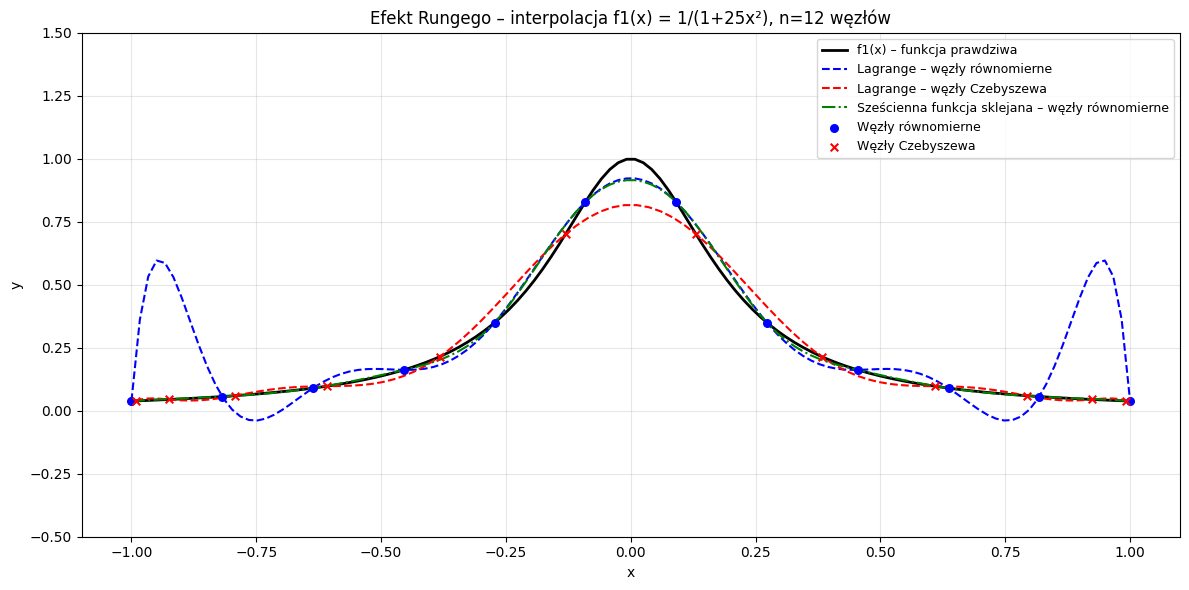

In [4]:
n = 12
a, b = -1, 1


x_unif = np.linspace(a, b, n)
y_unif = f1(x_unif)


x_cheb = np.sort(chebyshev_nodes(n, a, b))
y_cheb = f1(x_cheb)


x_dense_unif = np.linspace(a, b, 10 * n)
theta_dense = np.linspace(np.pi / (2 * n), np.pi * (2 * n - 1) / (2 * n), 10 * n)
x_dense_cheb = np.sort(np.cos(theta_dense))

y_true_unif = f1(x_dense_unif)
y_true_cheb = f1(x_dense_cheb)

y_lag_unif = lagrange_barycentric(x_unif, y_unif, x_dense_unif)
y_lag_cheb = lagrange_barycentric(x_cheb, y_cheb, x_dense_cheb)

cs_unif = CubicSpline(x_unif, y_unif)
y_spline_unif = cs_unif(x_dense_unif)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x_dense_unif, y_true_unif, 'k-', linewidth=2, label='f1(x) – funkcja prawdziwa')
ax.plot(x_dense_unif, y_lag_unif, 'b--', linewidth=1.5, label='Lagrange – węzły równomierne')
ax.plot(x_dense_cheb, y_lag_cheb, 'r--', linewidth=1.5, label='Lagrange – węzły Czebyszewa')
ax.plot(x_dense_unif, y_spline_unif, 'g-.', linewidth=1.5, label='Sześcienna funkcja sklejana – węzły równomierne')

ax.scatter(x_unif, y_unif, color='blue', zorder=5, s=30, label='Węzły równomierne')
ax.scatter(x_cheb, y_cheb, color='red', zorder=5, s=30, marker='x', label='Węzły Czebyszewa')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Efekt Rungego – interpolacja f1(x) = 1/(1+25x²), n={n} węzłów')
ax.legend(fontsize=9)
ax.set_ylim(-0.5, 1.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### (b) Norma błędu w zależności od liczby węzłów – f1(x)

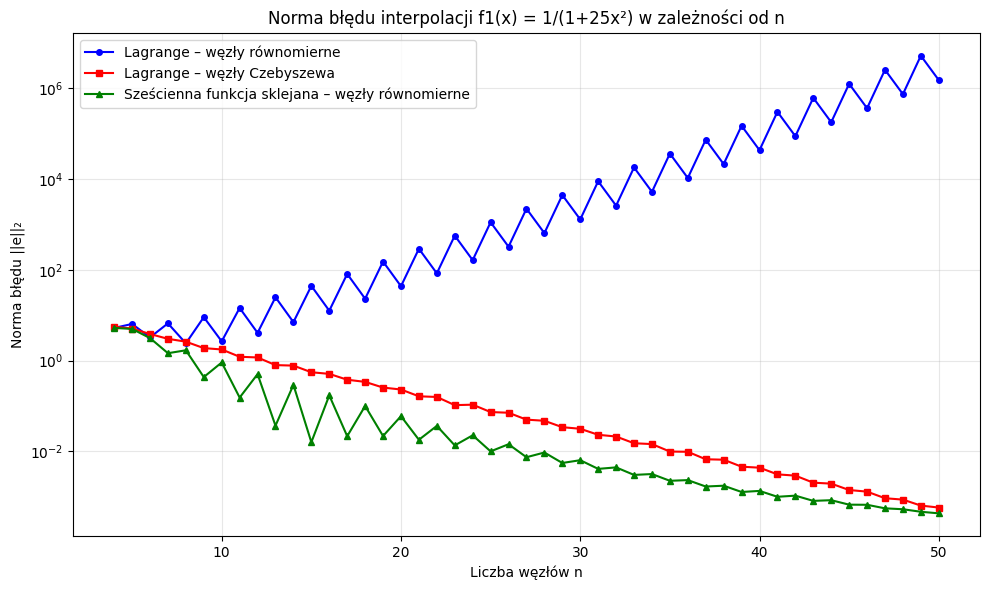

In [5]:
np.random.seed(42)

x_test_f1 = np.random.uniform(-1, 1, 500)
y_true_f1_test = f1(x_test_f1)

ns_range = range(4, 51)

err_lag_unif_f1  = []
err_lag_cheb_f1  = []
err_spline_unif_f1 = []

for n in ns_range:
    xn_u = np.linspace(-1, 1, n)
    yn_u = f1(xn_u)
    xn_c = np.sort(chebyshev_nodes(n, -1, 1))
    yn_c = f1(xn_c)

    yp = lagrange_barycentric(xn_u, yn_u, x_test_f1)
    err_lag_unif_f1.append(np.linalg.norm(yp - y_true_f1_test))

    yp = lagrange_barycentric(xn_c, yn_c, x_test_f1)
    err_lag_cheb_f1.append(np.linalg.norm(yp - y_true_f1_test))

    cs = CubicSpline(xn_u, yn_u)
    yp = cs(x_test_f1)
    err_spline_unif_f1.append(np.linalg.norm(yp - y_true_f1_test))

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(list(ns_range), err_lag_unif_f1,   'b-o', markersize=4, label='Lagrange – węzły równomierne')
ax.semilogy(list(ns_range), err_lag_cheb_f1,   'r-s', markersize=4, label='Lagrange – węzły Czebyszewa')
ax.semilogy(list(ns_range), err_spline_unif_f1, 'g-^', markersize=4, label='Sześcienna funkcja sklejana – węzły równomierne')
ax.set_xlabel('Liczba węzłów n')
ax.set_ylabel('Norma błędu ||e||₂')
ax.set_title('Norma błędu interpolacji f1(x) = 1/(1+25x²) w zależności od n')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


### (b) Norma błędu w zależności od liczby węzłów – f2(x)

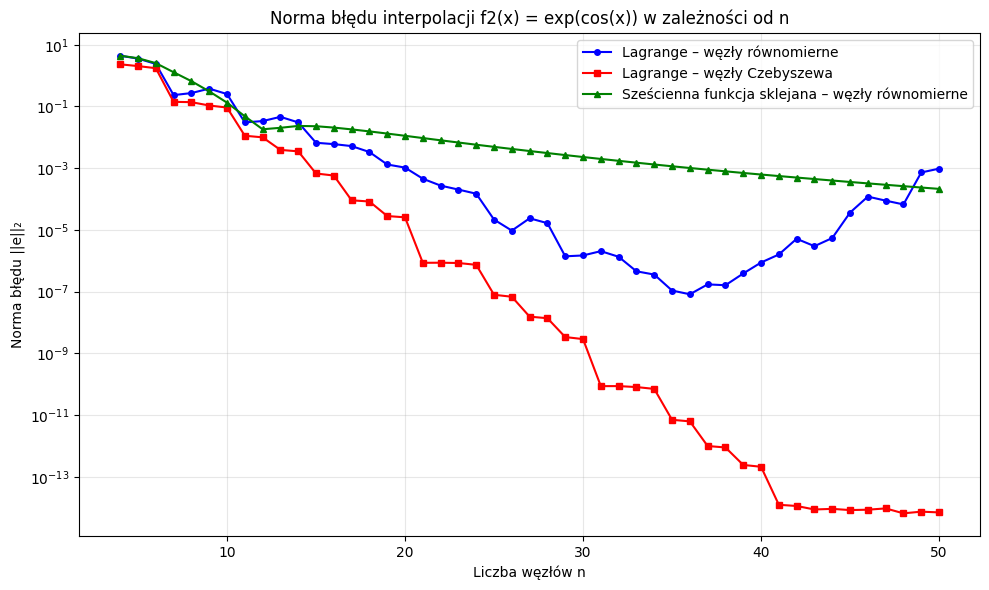

In [6]:
x_test_f2 = np.random.uniform(0, 2 * np.pi, 500)
y_true_f2_test = f2(x_test_f2)

err_lag_unif_f2  = []
err_lag_cheb_f2  = []
err_spline_unif_f2 = []

for n in ns_range:
    a2, b2 = 0, 2 * np.pi

    xn_u = np.linspace(a2, b2, n)
    yn_u = f2(xn_u)
    xn_c = np.sort(chebyshev_nodes(n, a2, b2))
    yn_c = f2(xn_c)

    yp = lagrange_barycentric(xn_u, yn_u, x_test_f2)
    err_lag_unif_f2.append(np.linalg.norm(yp - y_true_f2_test))

    yp = lagrange_barycentric(xn_c, yn_c, x_test_f2)
    err_lag_cheb_f2.append(np.linalg.norm(yp - y_true_f2_test))

    cs = CubicSpline(xn_u, yn_u)
    yp = cs(x_test_f2)
    err_spline_unif_f2.append(np.linalg.norm(yp - y_true_f2_test))

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(list(ns_range), err_lag_unif_f2,   'b-o', markersize=4, label='Lagrange – węzły równomierne')
ax.semilogy(list(ns_range), err_lag_cheb_f2,   'r-s', markersize=4, label='Lagrange – węzły Czebyszewa')
ax.semilogy(list(ns_range), err_spline_unif_f2, 'g-^', markersize=4, label='Sześcienna funkcja sklejana – węzły równomierne')
ax.set_xlabel('Liczba węzłów n')
ax.set_ylabel('Norma błędu ||e||₂')
ax.set_title('Norma błędu interpolacji f2(x) = exp(cos(x)) w zależności od n')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()
